In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Upload files
from google.colab import files
uploaded = files.upload()


Saving clean_sales.csv to clean_sales.csv


In [2]:
df=pd.read_csv("/content/clean_sales.csv")
print(df.shape)
print(df.dtypes)



(397636, 8)
invoiceno        int64
stockcode       object
description     object
quantity         int64
invoicedate     object
unitprice      float64
customerid       int64
country         object
dtype: object


In [3]:
df.head()


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom



**Fixing INVOICE Date Columns**



In [4]:
df['invoicedate']=pd.to_datetime(df['invoicedate'])
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


**Creating Revenue Coulmn**


In [5]:
df['revenue']=df['quantity']*df['unitprice']
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**Creating Month-Year Column**

In [6]:
df['month_year']=df['invoicedate'].dt.to_period('M')
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,month_year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [7]:
print(df.dtypes)
print(df['revenue'].sum().round(2))

invoiceno               int64
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid              int64
country                object
revenue               float64
month_year          period[M]
dtype: object
8908740.83


**Creating Visual Monthly Revenue Trend**

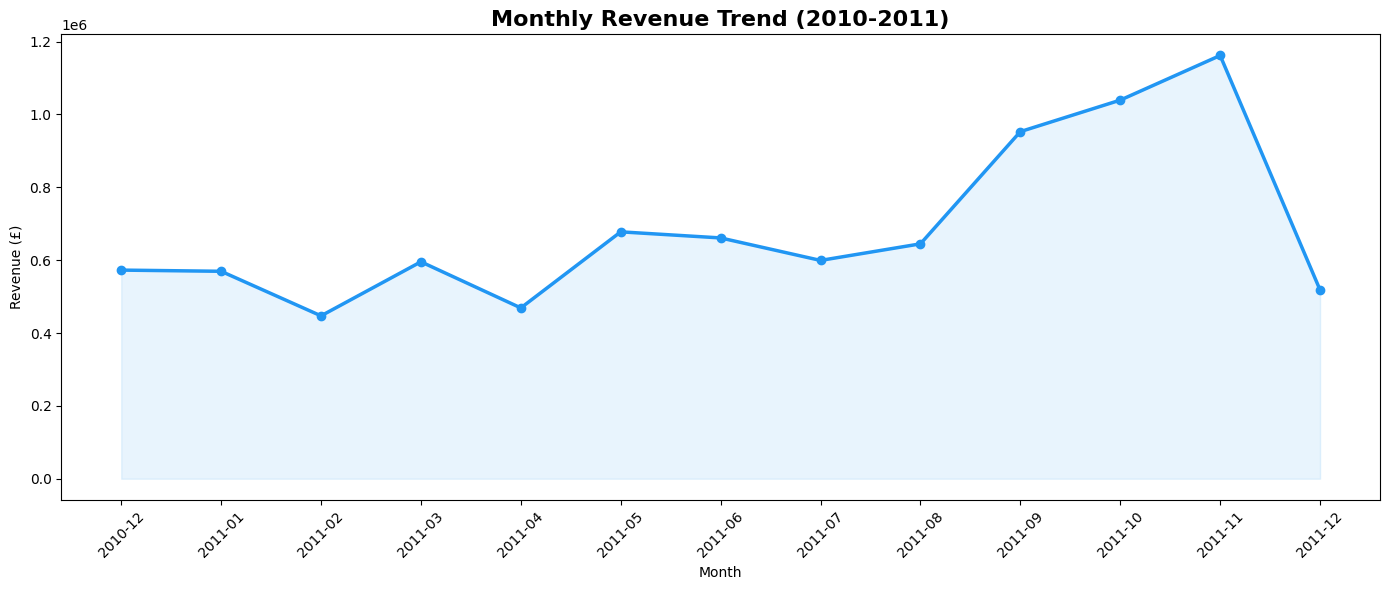

In [8]:
monthly_revenue=df.groupby('month_year')['revenue'].sum().reset_index()
monthly_revenue['month_year'] = monthly_revenue['month_year'].astype(str)
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['month_year'], monthly_revenue['revenue'],
         marker='o', color='#2196F3', linewidth=2.5, markersize=6)
plt.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'],
                 alpha=0.1, color='#2196F3')
plt.xticks(range(len(monthly_revenue)), monthly_revenue['month_year'], rotation=45)
plt.title('Monthly Revenue Trend (2010-2011)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

**TOP 10 Countries by Revenue**

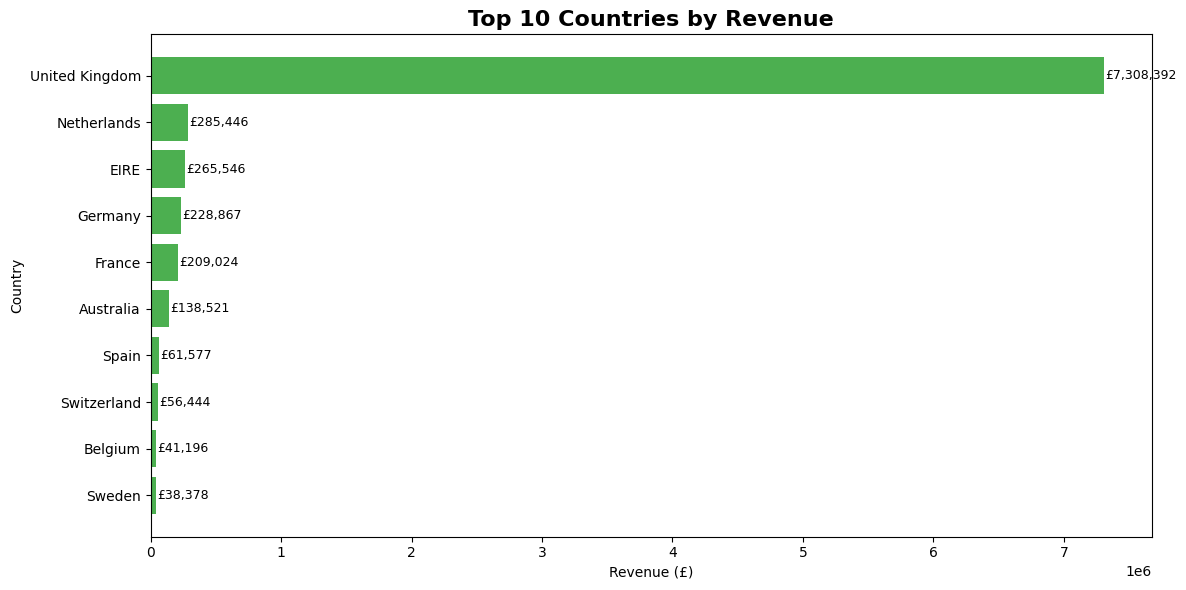

In [9]:
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.barh(country_revenue['country'][::-1], country_revenue['revenue'][::-1], color='#4CAF50')
plt.title('Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
for bar, val in zip(bars, country_revenue['revenue'][::-1]):
    plt.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150)
plt.show()

**TOP 10 Products by Revenue**

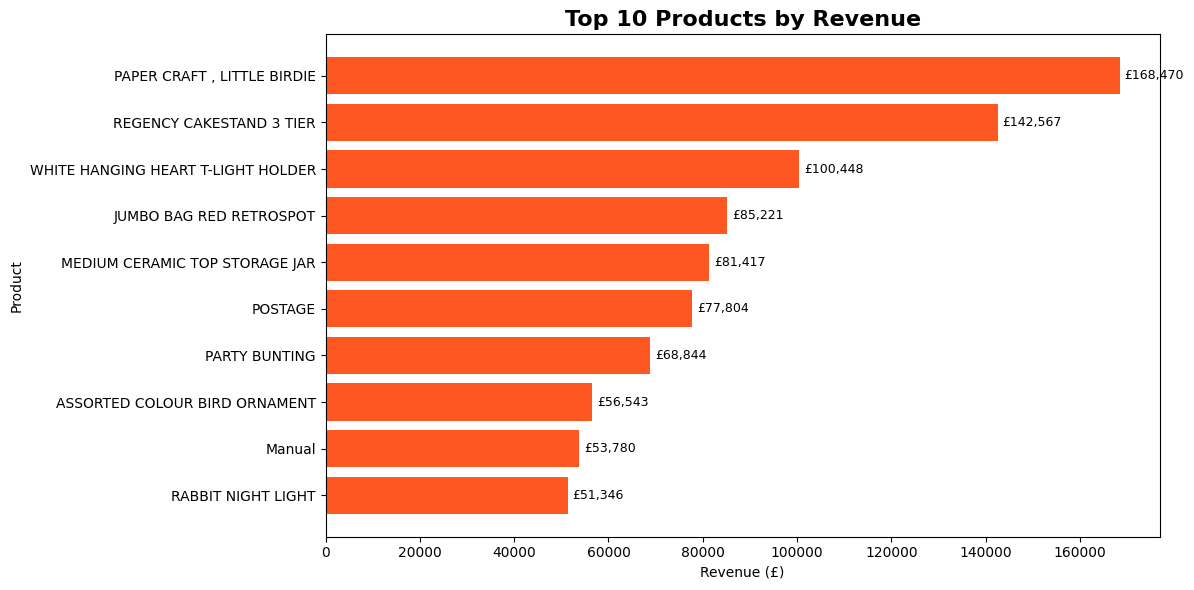

In [10]:
top_products = df.groupby('description')['revenue'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products['description'][::-1], top_products['revenue'][::-1], color='#FF5722')
plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
for bar, val in zip(bars, top_products['revenue'][::-1]):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

**RFM segmentation**

In [11]:
from google.colab import files
uploaded = files.upload()

Saving rfm_result.csv to rfm_result.csv


In [13]:
rfm = pd.read_csv('/content/rfm_result.csv')
print(rfm.head())

  customer_segment  total_customers  avg_revenue
0             Lost             1067       469.40
1            Loyal              983      1544.72
2              VIP              950      6054.89
3          At Risk              667      1271.72
4        Potential              355       470.67


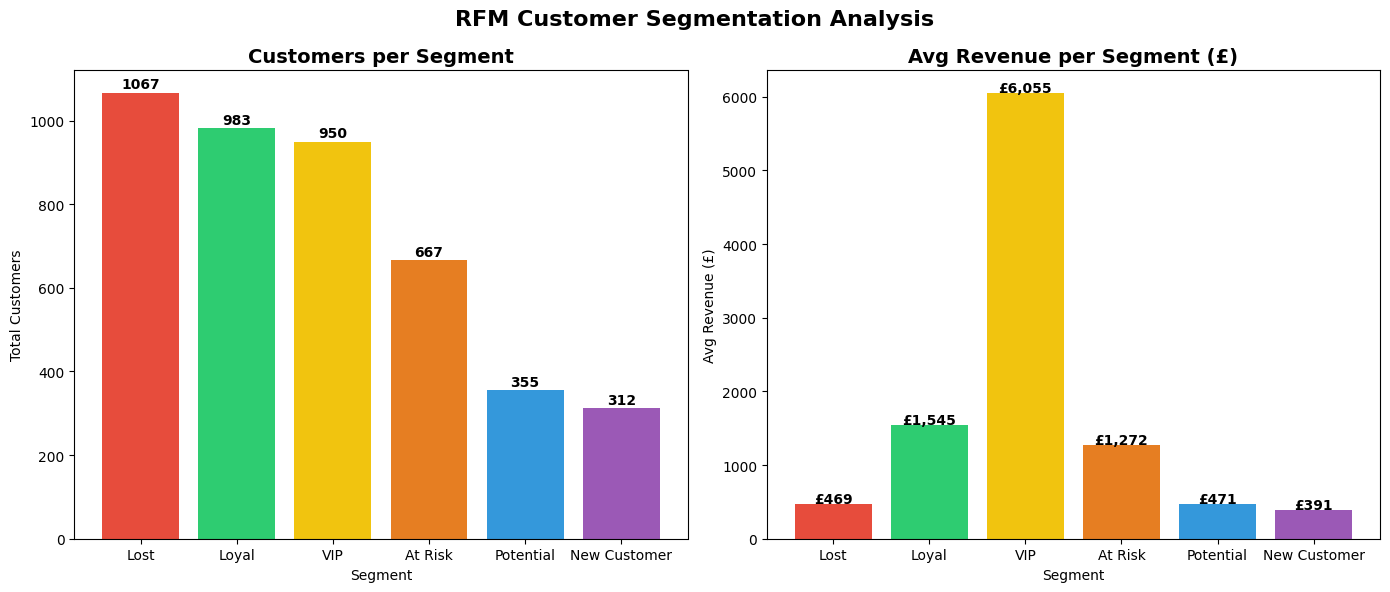

In [14]:
colors = ['#E74C3C', '#2ECC71', '#F1C40F', '#E67E22', '#3498DB', '#9B59B6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Customer Count
ax1.bar(rfm['customer_segment'], rfm['total_customers'], color=colors)
ax1.set_title('Customers per Segment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Total Customers')
for i, v in enumerate(rfm['total_customers']):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

# Chart 2 - Avg Revenue
ax2.bar(rfm['customer_segment'], rfm['avg_revenue'], color=colors)
ax2.set_title('Avg Revenue per Segment (£)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Avg Revenue (£)')
for i, v in enumerate(rfm['avg_revenue']):
    ax2.text(i, v + 10, f'£{v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download('clean_sales.csv')
files.download('/content/rfm_result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>